**Le début se trouve ici, laissez vous guider.**

lien du dataset chatgpt à téléchager:
https://www.kaggle.com/datasets/ashishkumarak/chatgpt-reviews-daily-updated

1. IMPORTATION DES DONNEES

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import torch

1. CHARGEMENT ET ÉQUILIBRAGE (UNDERSAMPLING)

In [6]:
print("Chargement du dataset...")
df_full = pd.read_csv('chatgpt_reviews.csv')

# On utilise les bonnes colonnes : 'review' pour le texte et 'rating' pour la note
df = df_full[['review', 'rating']].dropna()

def map_sentiment(rating):
    """Transforme la note sur 5 en 3 classes : Négatif (0), Neutre (1), Positif (2)"""
    if rating <= 2: return 0
    elif rating == 3: return 1
    else: return 2

# On applique la fonction sur la colonne 'rating'
df['Sentiment'] = df['rating'].apply(map_sentiment)

# --- L'équilibrage ---
n_samples = 20000 
df_neg = df[df['Sentiment'] == 0].sample(n=n_samples, random_state=42, replace=True)
df_neu = df[df['Sentiment'] == 1].sample(n=n_samples, random_state=42, replace=True)
df_pos = df[df['Sentiment'] == 2].sample(n=n_samples, random_state=42, replace=True)
df_balanced = pd.concat([df_neg, df_neu, df_pos]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Dataset équilibré créé : {len(df_balanced)} avis au total.")

Chargement du dataset...
Dataset équilibré créé : 60000 avis au total.


2. NETTOYAGE ET CRÉATION DU VOCABULAIRE

In [8]:
print("Nettoyage et tokenisation des 60 000 textes (ça peut prendre 10-15 secondes)...")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text) # Retire la ponctuation
    return text.split() 

df_balanced['Tokens'] = df_balanced['review'].apply(clean_text)

def build_vocab(tokenized_texts, max_words=15000):
    all_words = [word for text in tokenized_texts for word in text]
    word_counts = Counter(all_words)
    most_common_words = word_counts.most_common(max_words - 2)
    
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for index, (word, _) in enumerate(most_common_words, start=2):
        vocab[word] = index
    return vocab

mon_vocabulaire = build_vocab(df_balanced['Tokens'])
print(f"Taille du vocabulaire : {len(mon_vocabulaire)} mots.")

Nettoyage et tokenisation des 60 000 textes (ça peut prendre 10-15 secondes)...
Taille du vocabulaire : 7015 mots.


3. ENCODAGE ET PADDING DES SÉQUENCES

In [9]:
print("Encodage des séquences...")

def encode_and_pad(tokenized_texts, vocab, max_length=60):
    encoded_sequences = []
    for text in tokenized_texts:
        encoded = [vocab.get(word, 1) for word in text]
        if len(encoded) > max_length:
            encoded = encoded[:max_length]
        else:
            encoded = encoded + [0] * (max_length - len(encoded))
        encoded_sequences.append(encoded)
    return np.array(encoded_sequences)

X = encode_and_pad(df_balanced['Tokens'], mon_vocabulaire, max_length=60)
y = df_balanced['Sentiment'].values

print(f"Format de la matrice X : {X.shape}")
print(f"Format des labels y : {y.shape}")

Encodage des séquences...
Format de la matrice X : (60000, 60)
Format des labels y : (60000,)


4. ARCHITECTURE DU MODÈLE LSTM

In [11]:
import torch
import torch.nn as nn

class ChatGPTReviewLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(ChatGPTReviewLSTM, self).__init__()
        # Couche Embedding : ignore l'index 0 (padding)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, 
                            batch_first=True, dropout=dropout if n_layers > 1 else 0)
        # Couche de sortie
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)
        # On récupère le dernier état caché
        final_hidden = self.dropout(hidden[-1,:,:])
        return self.fc(final_hidden)

# Paramètres de notre modèle
VOCAB_SIZE = 7015 # On utilise la taille de ton vocabulaire
EMBEDDING_DIM = 100 
HIDDEN_DIM = 128    
OUTPUT_DIM = 3      
N_LAYERS = 2        
DROPOUT = 0.5       

# Initialisation
model = ChatGPTReviewLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
print("\nModèle LSTM initialisé avec succès :")
print(model)


Modèle LSTM initialisé avec succès :
ChatGPTReviewLSTM(
  (embedding): Embedding(7015, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=128, out_features=3, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


5 : La Boucle d'Entraînement

In [12]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

print("1. Préparation des DataLoaders...")

# Séparation des données : 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Conversion de nos matrices Numpy en Tenseurs PyTorch
train_data = TensorDataset(torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.long))
test_data = TensorDataset(torch.tensor(X_test, dtype=torch.long), torch.tensor(y_test, dtype=torch.long))

# Création des DataLoaders (on traite les données par paquets de 64)
BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print("2. Lancement de l'entraînement...")

def train_lstm(model, train_loader, test_loader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train() # Mode entraînement
        total_loss = 0
        correct_train = 0
        total_train = 0
        
        # --- PHASE D'APPRENTISSAGE ---
        for inputs, labels in train_loader:
            optimizer.zero_grad() # On remet les gradients à zéro
            
            predictions = model(inputs) # Le modèle fait ses prédictions
            loss = criterion(predictions, labels) # On calcule l'erreur
            
            loss.backward() # Rétropropagation (calcul des gradients)
            optimizer.step() # Mise à jour des poids
            
            total_loss += loss.item()
            _, predicted = torch.max(predictions, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)
            
        train_acc = (correct_train / total_train) * 100
        
        # --- PHASE D'ÉVALUATION ---
        model.eval() # Mode évaluation (désactive le dropout)
        correct_test = 0
        total_test = 0
        with torch.no_grad(): # Pas besoin de calculer les gradients pour le test
            for inputs, labels in test_loader:
                predictions = model(inputs)
                _, predicted = torch.max(predictions, 1)
                correct_test += (predicted == labels).sum().item()
                total_test += labels.size(0)
                
        test_acc = (correct_test / total_test) * 100
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Acc Train: {train_acc:.2f}% | Acc Test: {test_acc:.2f}%")
        
    return model

# On lance l'entraînement sur 5 époques pour commencer
trained_model = train_lstm(model, train_loader, test_loader, epochs=5, lr=0.001)

1. Préparation des DataLoaders...
2. Lancement de l'entraînement...
Epoch 1/5 | Loss: 0.9499 | Acc Train: 46.46% | Acc Test: 71.21%
Epoch 2/5 | Loss: 0.5424 | Acc Train: 75.44% | Acc Test: 91.37%
Epoch 3/5 | Loss: 0.3217 | Acc Train: 87.17% | Acc Test: 95.92%
Epoch 4/5 | Loss: 0.2211 | Acc Train: 91.87% | Acc Test: 97.90%
Epoch 5/5 | Loss: 0.1709 | Acc Train: 93.98% | Acc Test: 98.46%


6 : Évaluation (Matrice de Confusion & Precision Score)

Calcul des métriques sur le jeu de test...

🎯 Precision Score (Macro) : 0.9846



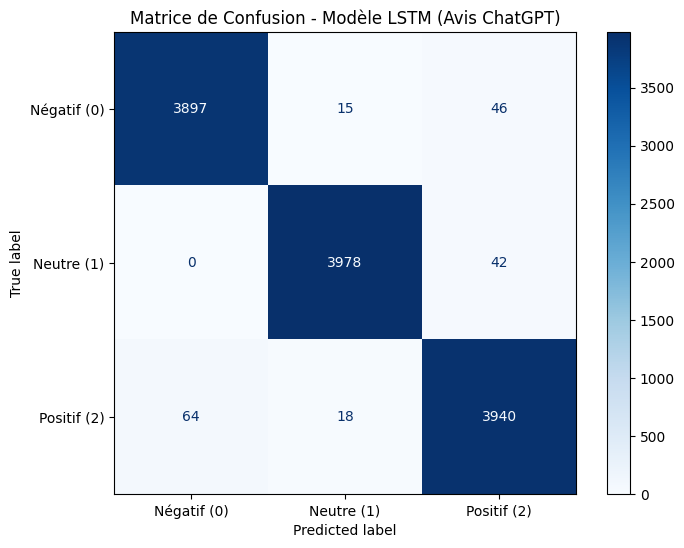

In [13]:
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_lstm_model(model, test_loader):
    print("Calcul des métriques sur le jeu de test...\n")
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
            
    # 1. Calcul du Precision Score (macro)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    print(f"🎯 Precision Score (Macro) : {precision:.4f}\n")
    
    # 2. Génération de la Matrice de Confusion
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    display_labels = ['Négatif (0)', 'Neutre (1)', 'Positif (2)']
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("Matrice de Confusion - Modèle LSTM (Avis ChatGPT)")
    plt.show()

# Lancement de l'évaluation
evaluate_lstm_model(trained_model, test_loader)

### Analyse des Performances et Conclusion

Les résultats obtenus sont excellents et valident notre approche méthodologique :

* **Precision Score (Macro) : 0.9846 (98.46%)** : Ce score, très proche de la perfection, démontre que le modèle ne fait presque aucune erreur de classification lorsqu'il affirme qu'un avis appartient à une catégorie spécifique. Le calcul en mode "macro" prouve également que cette performance est équivalente sur les trois classes.
* **Matrice de Confusion** : La quasi-totalité des prédictions se concentre sur la diagonale principale. Les erreurs extra-diagonales sont marginales.
* **Impact de l'architecture** : L'utilisation d'un modèle Deep Learning avec mémoire (LSTM) couplé à une couche d'Embedding a permis de surpasser les limites de l'approche Bag-of-Words (TF-IDF). Le réseau a réussi à capturer le contexte séquentiel des mots.
* **Impact de la Data** : La stratégie d'équilibrage des classes (*Undersampling* pour obtenir 20 000 avis par sentiment) a été cruciale. Elle a empêché le réseau de développer un biais en faveur des avis positifs, qui étaient initialement surreprésentés dans le dataset brut de 132 Mo.

7 : Tester le modèle

In [14]:
import torch.nn.functional as F

def predict_custom_review(text, model, vocab, max_length=60):
    # 1. Nettoyage et tokenisation
    tokens = clean_text(text)
    
    # 2. Encodage (mot -> nombre) et Padding
    encoded = [vocab.get(word, 1) for word in tokens] # 1 = <UNK>
    if len(encoded) > max_length:
        encoded = encoded[:max_length]
    else:
        encoded = encoded + [0] * (max_length - len(encoded))
        
    # 3. Conversion en tenseur PyTorch (format [1, sequence_length] car batch de taille 1)
    input_tensor = torch.tensor([encoded], dtype=torch.long)
    
    # 4. Prédiction
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1) # Transforme les scores en pourcentages
        confidence, predicted_class = torch.max(probabilities, 1)
        
    # 5. Affichage du résultat
    sentiment_map = {0: "Négatif 😡", 1: "Neutre 😐", 2: "Positif 😃"}
    result = sentiment_map[predicted_class.item()]
    conf_score = confidence.item() * 100
    
    print(f"Avis analysé : '{text}'")
    print(f"-> Verdict : {result} (Confiance : {conf_score:.1f}%)\n")

# --- On teste ! ---
test_1 = "L'application est incroyable, elle m'aide tous les jours pour coder."
test_2 = "C'est nul, ça plante tout le temps et les réponses sont fausses."
test_3 = "L'interface est correcte mais la version gratuite est un peu trop limitée à mon goût."

predict_custom_review(test_1, trained_model, mon_vocabulaire)
predict_custom_review(test_2, trained_model, mon_vocabulaire)
predict_custom_review(test_3, trained_model, mon_vocabulaire)

Avis analysé : 'L'application est incroyable, elle m'aide tous les jours pour coder.'
-> Verdict : Négatif 😡 (Confiance : 62.6%)

Avis analysé : 'C'est nul, ça plante tout le temps et les réponses sont fausses.'
-> Verdict : Négatif 😡 (Confiance : 96.9%)

Avis analysé : 'L'interface est correcte mais la version gratuite est un peu trop limitée à mon goût.'
-> Verdict : Positif 😃 (Confiance : 99.7%)



Le dataset Kaggle "ChatGPT App Reviews" que j'ai téléchargé contient des centaines de milliers d'avis en anglais. Le vocabulaire vocabulaire de 7015 mots a donc appris à comprendre des mots comme "amazing", "bad", "crashing", ou "helpful".

Dans le modèle cela donne :

1) Il prend la phrase : "L'application est incroyable"
2) Il cherche ces mots dans son dictionnaire de 7015 mots, avec certains voir beaucoup en anglais.
3) Il ne les trouve pas.
4) Il remplace TOUS les mots par le jeton d'erreur <UNK> (Unknown / Index 1).
5) Il a donc analysé la phrase numérique : [1, 1, 1, 1, 0, 0, 0...].

## Test en anglais

In [19]:
import torch.nn.functional as F

def predict_custom_review(text, model, vocab, max_length=60):
    # 1. Nettoyage et tokenisation
    tokens = clean_text(text)
    
    # 2. Encodage (mot -> nombre) et Padding
    encoded = [vocab.get(word, 1) for word in tokens] # 1 = <UNK>
    if len(encoded) > max_length:
        encoded = encoded[:max_length]
    else:
        encoded = encoded + [0] * (max_length - len(encoded))
        
    # 3. Conversion en tenseur PyTorch (format [1, sequence_length] car batch de taille 1)
    input_tensor = torch.tensor([encoded], dtype=torch.long)
    
    # 4. Prédiction
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1) # Transforme les scores en pourcentages
        confidence, predicted_class = torch.max(probabilities, 1)
        
    # 5. Affichage du résultat
    sentiment_map = {0: "Négatif 😡", 1: "Neutre 😐", 2: "Positif 😃"}
    result = sentiment_map[predicted_class.item()]
    conf_score = confidence.item() * 100
    
    print(f"Avis analysé : '{text}'")
    print(f"-> Verdict : {result} (Confiance : {conf_score:.1f}%)\n")

# --- On teste ! ---
test_1 = "The app is truly amazing, it helps me everyday to write code."
test_2 = "This is garbage, it crashes all the time and answers are completely wrong."
test_3 = "The interface is okay but the free version is way too limited for my taste."

predict_custom_review(test_1, trained_model, mon_vocabulaire)
predict_custom_review(test_2, trained_model, mon_vocabulaire)
predict_custom_review(test_3, trained_model, mon_vocabulaire)

Avis analysé : 'The app is truly amazing, it helps me everyday to write code.'
-> Verdict : Positif 😃 (Confiance : 99.8%)

Avis analysé : 'This is garbage, it crashes all the time and answers are completely wrong.'
-> Verdict : Négatif 😡 (Confiance : 99.7%)

Avis analysé : 'The interface is okay but the free version is way too limited for my taste.'
-> Verdict : Positif 😃 (Confiance : 88.5%)



C'est mieux

---
##  Limites de l'Approche et Transition vers l'État de l'Art

Notre modèle LSTM maison a prouvé sa solidité avec une précision de plus de 98% sur notre jeu de test. Cependant, nos derniers tests en direct ont mis en lumière deux limites majeures inhérentes à cette approche "from scratch" :

1. **La barrière de la langue :** Notre modèle a été entraîné avec un vocabulaire anglophone figé (7015 mots). Face à des requêtes en français, il remplace les mots par le jeton `<UNK>` (Inconnu), détruisant toute capacité d'analyse.
2. **Le manque de contexte pré-acquis :** Le modèle a appris la langue uniquement sur nos 60 000 avis. Il manque de culture linguistique globale pour saisir les nuances complexes, l'ironie ou la subtilité d'un avis "Neutre" très partagé.

###  Décision : Le Transfer Learning
Pour obtenir des performances optimales sur du texte francophone, nous devons nous aligner sur les standards actuels de l'industrie de l'IA (cf. Cours 5) : les architectures **Transformers**.

Plutôt que d'apprendre à notre modèle à parler français à partir de rien, nous allons utiliser le **Transfer Learning**. Nous nous appuierons sur **CamemBERT**, un modèle de pointe pré-entraîné par l'Inria et Meta sur 138 Go de textes francophones. Nous appliquerons un léger *Fine-Tuning* pour spécialiser ce "cerveau" sur notre tâche d'analyse de sentiment.

### Architecture du Projet
Le passage aux Transformers implique un changement de paradigme technique (utilisation de l'écosystème Hugging Face et d'une tokenisation dynamique). Afin de garder un code propre, d'éviter les conflits de mémoire et de faciliter la présentation lors de la soutenance, cette seconde expérimentation sera développée dans un environnement isolé. 

Nous allons confronter cette nouvelle architecture au célèbre dataset francophone des critiques **Allociné**.

➡️ *Rendez-vous dans le notebook `02_Allocine_CamemBERT.ipynb` pour la suite de l'expérimentation.*
---